In [ ]:
# %%
# CELDA 1: CARGA DE HERRAMIENTAS, DATOS Y LIMPIEZA TOTAL (CORREGIDA ✅)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar la base de datos de índices de educación
path = 'csv/BaseINDICES-2020-2025.csv'
df = pd.read_csv(path, sep=';', encoding='utf-8')

# Nos enfocamos en el último año consolidado para la charla
df = df[df['Año'] == 2025].copy()

# --- EL ARREGLO ESTÁ AQUÍ: Limpieza segura de dinero y personas ---
cols_dinero_personas = ['Matrícula primer año hombres', 'Matrícula primer año mujeres', 'Vacantes', 'Matrícula Primer Año', 'Valor de arancel', 'Matrícula Total']
for col in cols_dinero_personas:
    # Solo aplicamos reemplazos de texto si Pandas leyó la columna como 'object' (string)
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Limpieza segura de puntajes PAES y NEM
cols_puntajes = ['Promedio Puntaje (promedio matemáticas y lenguaje)', 'Promedio Puntaje NEM', 'Puntaje de corte (último seleccionado)']
for col in cols_puntajes:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Nos quedamos únicamente con las carreras que sean "Ingeniería"
df_ing = df[df['Carrera Genérica'].str.contains('Ingeniería', case=False, na=False)].copy()

# Clasificador por áreas reales de la ingeniería
def clasificar_area(carrera):
    c = str(carrera).lower()
    if 'computación' in c or 'informática' in c or 'sistemas' in c:
        return 'Informática y Software'
    elif 'industrial' in c or 'gestión' in c or 'comercial' in c:
        return 'Industrial y Gestión'
    elif 'civil' in c and ('obras' in c or 'construcción' in c or 'infraestructura' in c):
        return 'Civil y Construcción'
    elif 'mecánica' in c or 'eléctrica' in c or 'electrónica' in c or 'automatización' in c:
        return 'Mecánica y Eléctrica'
    elif 'química' in c or 'biotecnología' in c or 'ambiental' in c or 'minas' in c:
        return 'Procesos, Minas y Ambiente'
    else:
        return 'Otras Ingenierías'

df_ing['Area_Ingenieria'] = df_ing['Carrera Genérica'].apply(clasificar_area)

# Estética moderna global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ DATOS LISTOS Y CORREGIDOS: Todo cargado con las vacantes reales en memoria.")

✅ DATOS LISTOS Y CORREGIDOS: Todo cargado con las vacantes reales en memoria.


In [20]:
# %% [markdown]
# # 📈 EVOLUCIÓN MACRO: LA FACULTAD DE INGENIERÍA (2020 - 2025)
# #### Carga de datos y unificación de todas las carreras bajo el bloque único de "Ingeniería".

# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar el archivo histórico de evolución temporal
path = 'csv/BaseINDICES-2020-2025.csv'

try:
    df_historico = pd.read_csv(path, sep=';', encoding='utf-8')
except Exception:
    df_historico = pd.read_csv(path, sep=',', encoding='utf-8')

# 2. Limpieza estricta de datos numéricos
cols_dinero_personas = ['Matrícula primer año hombres', 'Matrícula primer año mujeres', 'Vacantes', 'Matrícula Primer Año', 'Valor de arancel', 'Matrícula Total']
for col in cols_dinero_personas:
    if col in df_historico.columns and df_historico[col].dtype == 'object':
        df_historico[col] = df_historico[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_historico[col] = pd.to_numeric(df_historico[col], errors='coerce')

# Asegurar el formato entero para los años
df_historico['Año'] = pd.to_numeric(df_historico['Año'], errors='coerce').astype(int)

# Filtramos para asegurarnos que todo lo que esté en el dataframe sea Ingeniería
df_ing = df_historico[df_historico['Carrera Genérica'].str.contains('Ingeniería', case=False, na=False)].copy()

# Estética visual limpia y profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

print(f"✅ DATOS UNIFICADOS: Analizando toda la Ingeniería en conjunto desde el año {df_ing['Año'].min()} al {df_ing['Año'].max()}")

✅ DATOS UNIFICADOS: Analizando toda la Ingeniería en conjunto desde el año 2020 al 2025


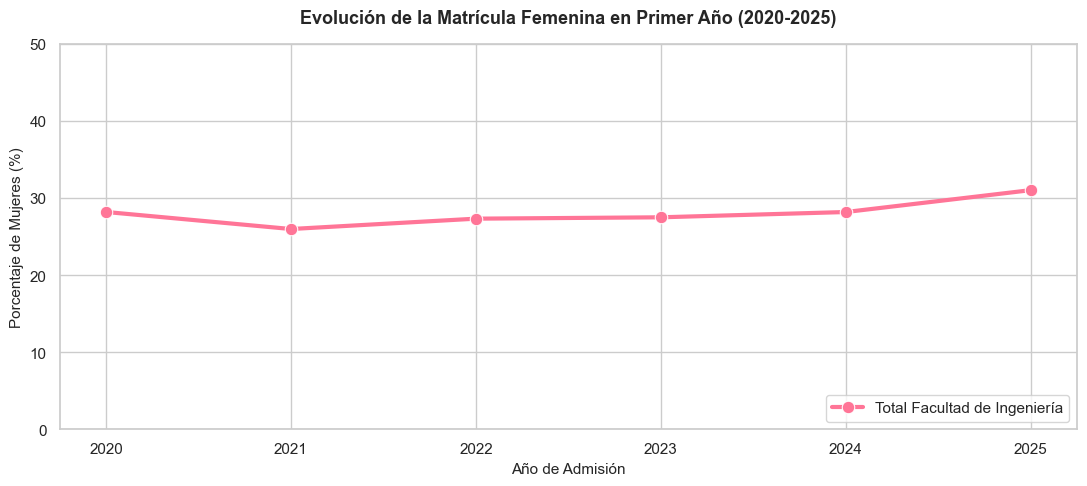

In [21]:
# %% [markdown]
# ## 📉 HISTÓRICO 1: Evolución General del Ingreso Femenino
# Muestra la tendencia neta del porcentaje de mujeres que entran a la Facultad de Ingeniería año a año.

# %%
plt.figure()

# Agrupamos únicamente por Año sumando toda la facultad
df_genero_total = df_ing.groupby('Año')[['Matrícula primer año hombres', 'Matrícula primer año mujeres']].sum().reset_index()

# Calculamos el porcentaje global de mujeres en la facultad
total_ingreso = df_genero_total['Matrícula primer año hombres'] + df_genero_total['Matrícula primer año mujeres']
df_genero_total['Pct_Mujeres'] = (df_genero_total['Matrícula primer año mujeres'] / total_ingreso) * 100

# Graficamos la línea de tendencia de la facultad
sns.lineplot(
    data=df_genero_total, 
    x='Año', 
    y='Pct_Mujeres', 
    marker='o', 
    markersize=9, 
    linewidth=3, 
    color='#ff7597',
    label='Total Facultad de Ingeniería'
)

plt.title('Evolución de la Matrícula Femenina en Primer Año (2020-2025)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Año de Admisión', fontsize=11)
plt.ylabel('Porcentaje de Mujeres (%)', fontsize=11)
plt.ylim(0, 50) # Escala fija de 0 a 50% para ver la proporción real respecto a la paridad
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig('macro_evolucion_genero.png', dpi=300, bbox_inches='tight')

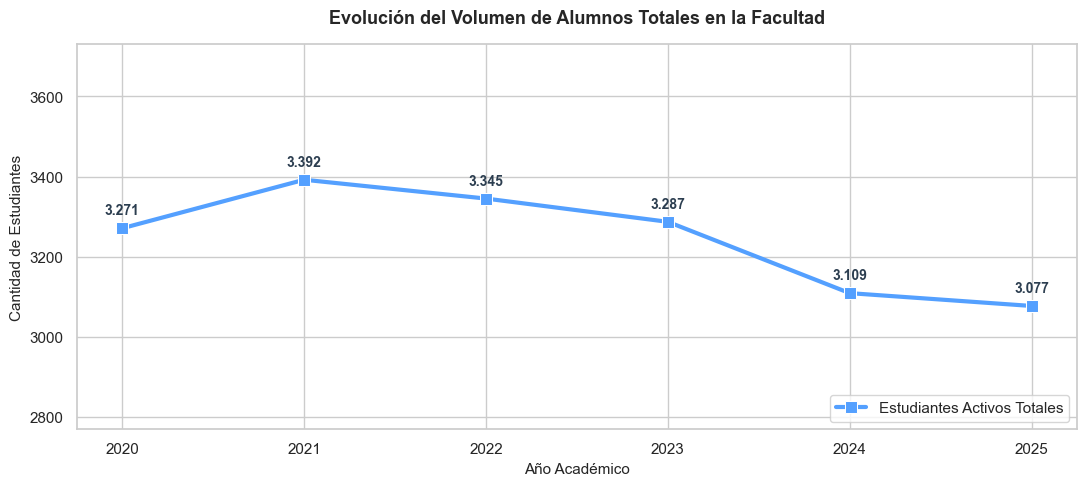

In [22]:
# %% [markdown]
# ## 🏢 HISTÓRICO 2: Crecimiento de la Matrícula Total de Ingeniería
# Muestra cuántos estudiantes activos en total (de todos los años) componen la facultad a lo largo del tiempo.

# %%
plt.figure()

# Sumamos la matrícula total de toda la ingeniería por año
df_masa_total = df_ing.groupby('Año')['Matrícula Total'].sum().reset_index()

sns.lineplot(
    data=df_masa_total, 
    x='Año', 
    y='Matrícula Total', 
    marker='s', 
    markersize=9, 
    linewidth=3, 
    color='#54a0ff',
    label='Estudiantes Activos Totales'
)

# Añadir los números exactos sobre cada nodo para que la escala sea transparente
for x, y in zip(df_masa_total['Año'], df_masa_total['Matrícula Total']):
    if not np.isnan(y):
        plt.annotate(
            f'{int(y):,}'.replace(',', '.'), 
            (x, y), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=10, 
            fontweight='bold',
            color='#2c3e50'
        )

plt.title('Evolución del Volumen de Alumnos Totales en la Facultad', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Año Académico', fontsize=11)
plt.ylabel('Cantidad de Estudiantes', fontsize=11)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(loc='lower right')

# Le damos un aire arriba en el eje Y para que las etiquetas de los números no se corten
plt.ylim(df_masa_total['Matrícula Total'].min() * 0.9, df_masa_total['Matrícula Total'].max() * 1.1)

plt.tight_layout()
plt.savefig('macro_evolucion_masividad.png', dpi=300, bbox_inches='tight')

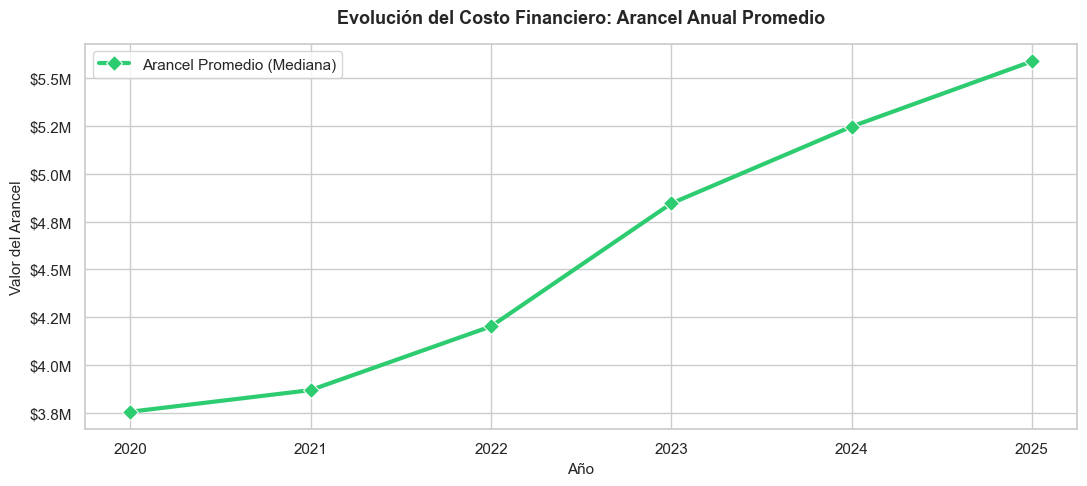

In [23]:
# %% [markdown]
# ## 💰 HISTÓRICO 3: La Curva de Aranceles Promedio de la Facultad
# Revela la tendencia del costo financiero medio de estudiar una ingeniería en este periodo.

# %%
plt.figure()

# Calculamos la mediana del arancel de toda la ingeniería por año
df_precio_total = df_ing.groupby('Año')['Valor de arancel'].median().reset_index()

sns.lineplot(
    data=df_precio_total, 
    x='Año', 
    y='Valor de arancel', 
    marker='D', 
    markersize=8, 
    linewidth=3, 
    color='#2ecc71',
    label='Arancel Promedio (Mediana)'
)

# Formateamos el eje Y a formato de millones tradicionales chilenos ($4.8M)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.title('Evolución del Costo Financiero: Arancel Anual Promedio', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=11)
plt.ylabel('Valor del Arancel', fontsize=11)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('macro_evolucion_aranceles.png', dpi=300, bbox_inches='tight')

C:\Users\iancu\AppData\Local\Temp\ipykernel_11288\3826360654.py:21: UserWarning: Glyph 128102 (\N{BOY}) missing from font(s) Arial.
  plt.savefig('visual_genero_ingenierias.png', dpi=500, bbox_inches='tight')
C:\Users\iancu\AppData\Local\Temp\ipykernel_11288\3826360654.py:21: UserWarning: Glyph 128103 (\N{GIRL}) missing from font(s) Arial.
  plt.savefig('visual_genero_ingenierias.png', dpi=500, bbox_inches='tight')
c:\Users\iancu\OneDrive\Escritorio\github_repos\pyhtones\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128102 (\N{BOY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\iancu\OneDrive\Escritorio\github_repos\pyhtones\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128103 (\N{GIRL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


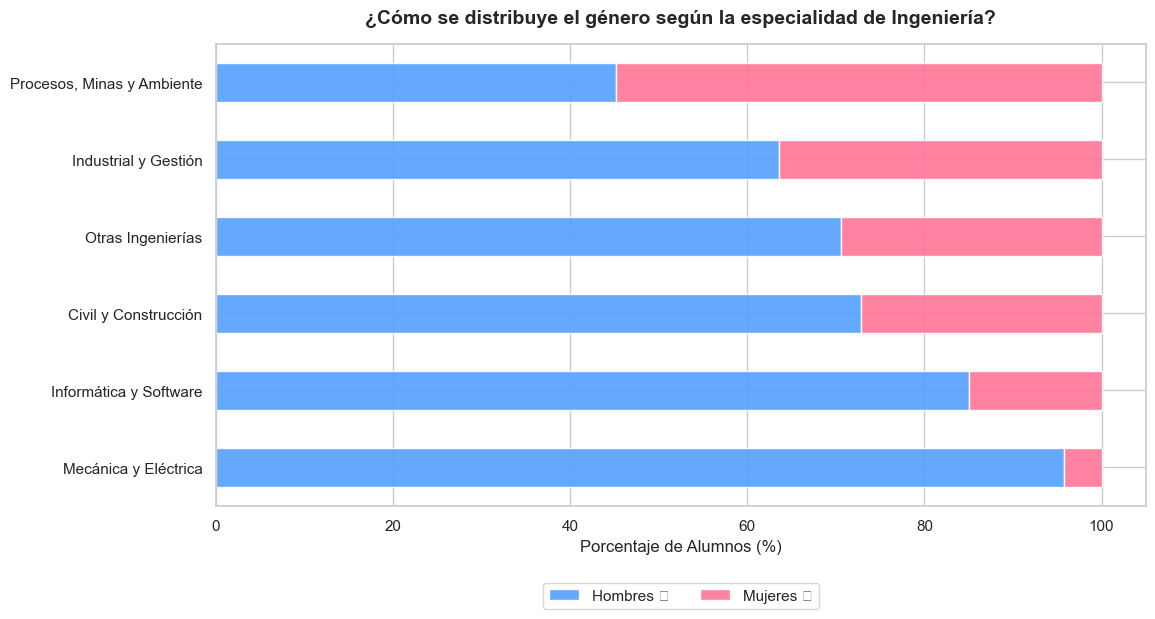

In [12]:
# %% [markdown]
# ## 📊 GRÁFICO 1: La Balanza de Género por Especialidad
# Vamos a derribar mitos analizando cómo se distribuyen hombres y mujeres en el primer año.

# %%
plt.figure(figsize=(12, 6))

# Agrupar y calcular porcentajes apilados de género
df_gender = df_ing.groupby('Area_Ingenieria')[['Matrícula primer año hombres', 'Matrícula primer año mujeres']].sum()
df_gender_pct = df_gender.div(df_gender.sum(axis=1), axis=0) * 100
df_gender_pct = df_gender_pct.sort_values('Matrícula primer año mujeres', ascending=True)

# Dibujar barras horizontales con colores modernos
df_gender_pct.plot(kind='barh', stacked=True, color=['#54a0ff', '#ff7597'], alpha=0.9, ax=plt.gca())

plt.title('¿Cómo se distribuye el género según la especialidad de Ingeniería?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Alumnos (%)', fontsize=12)
plt.ylabel('')
plt.legend(['Hombres 👦', 'Mujeres 👧'], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.savefig('visual_genero_ingenierias.png', dpi=500, bbox_inches='tight')
plt.show()

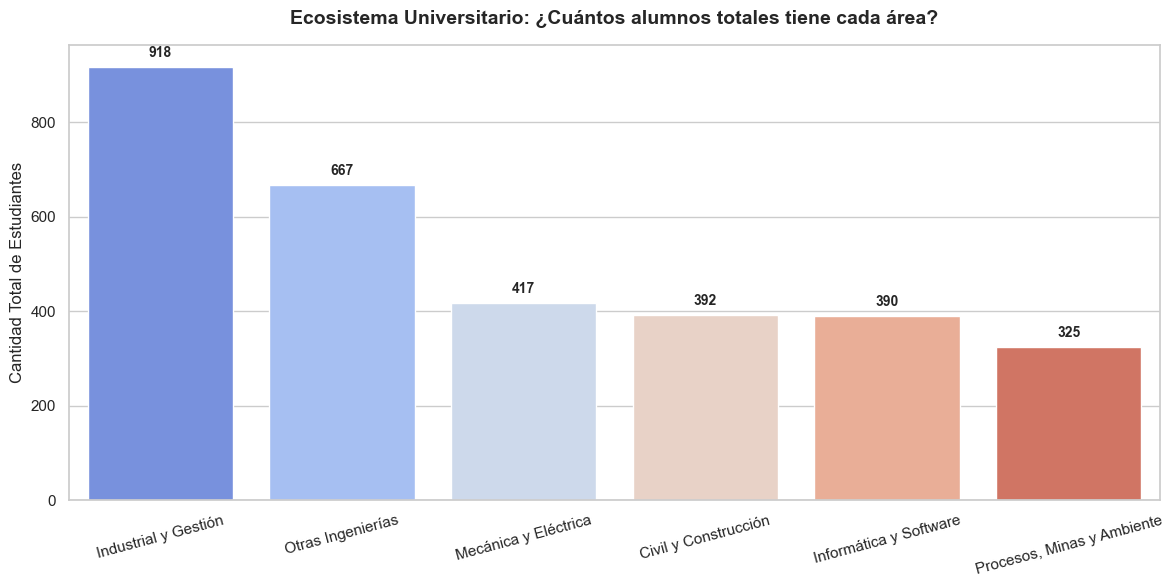

In [15]:
# %% [markdown]
# ## 🏢 GRÁFICO 6: El "Peso" de las Especialidades (Alumnos Totales)
# ¿Dónde está la masa estudiantil? Este gráfico muestra la cantidad total de personas que están estudiando cada área en Chile hoy.

# %%
plt.figure(figsize=(12, 6))

# Sumamos la matrícula total de todos los años de carrera por área
df_masividad = df_ing.groupby('Area_Ingenieria')['Matrícula Total'].sum().reset_index()
df_masividad = df_masividad.sort_values('Matrícula Total', ascending=False)

# Graficamos con un gráfico de barras verticales moderno
ax = sns.barplot(
    data=df_masividad, 
    x='Area_Ingenieria', 
    y='Matrícula Total', 
    hue='Area_Ingenieria',
    palette='coolwarm', 
    dodge=False,
    legend=False
)

# Añadimos etiquetas arriba de cada barra con el número de alumnos formateado con puntos de miles
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height):,}'.replace(',', '.'), # Formato chileno con puntos
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold',
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.title('Ecosistema Universitario: ¿Cuántos alumnos totales tiene cada área?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('', fontsize=12)
plt.ylabel('Cantidad Total de Estudiantes', fontsize=12)
plt.xticks(rotation=15) # Un pequeño ángulo para que no se choquen los nombres

plt.tight_layout()
plt.savefig('visual_masividad_ingenierias.png', dpi=300, bbox_inches='tight')
plt.show()

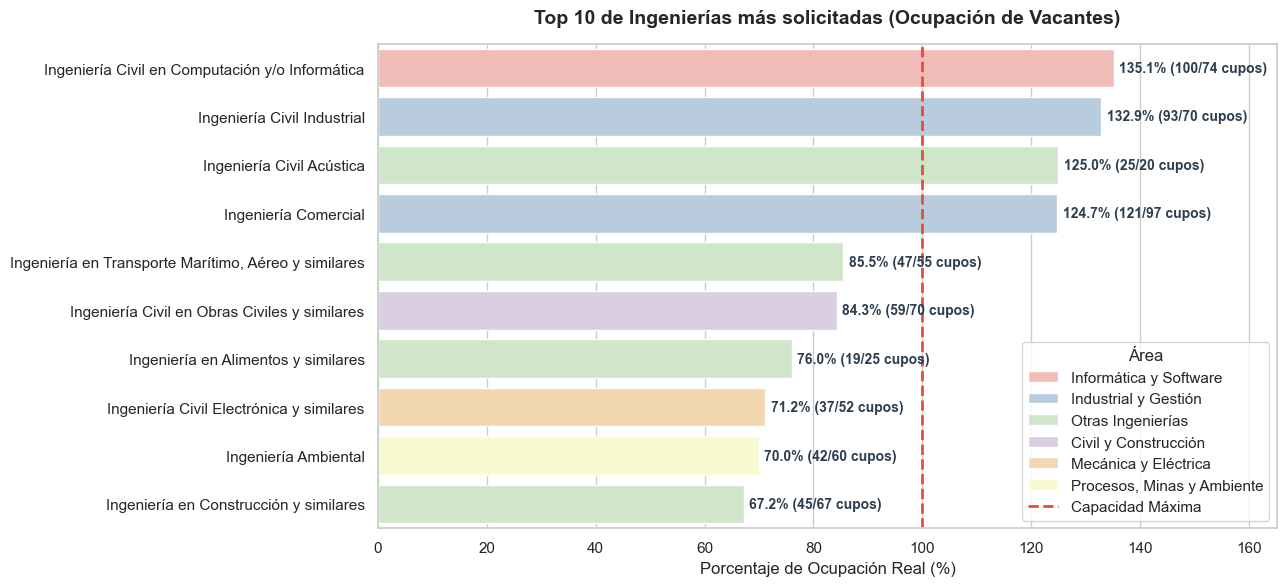

In [11]:
# %% [markdown]
# ## 🔥 GRÁFICO 3: Las Más Cotizadas (Ocupación de Vacantes con Contexto Real)
# Muestra el porcentaje de éxito, pero exponiendo explícitamente cuántos cupos reales se juegan.

# %%
plt.figure(figsize=(13, 6))

# 1. Agrupamos sumando los valores absolutos primero (así la escala es real a nivel nacional)
df_carreras = df_ing.groupby(['Carrera Genérica', 'Area_Ingenieria'])[['Matrícula Primer Año', 'Vacantes']].sum().reset_index()

# 2. Calculamos la tasa sobre los totales sumados
df_carreras['Tasa_Llenado'] = (df_carreras['Matrícula Primer Año'] / df_carreras['Vacantes']) * 100

# 3. Filtramos el Top 10
df_top_llenado = df_carreras.sort_values('Tasa_Llenado', ascending=False).head(10)

# Graficar el Top 10
ax = sns.barplot(data=df_top_llenado, x='Tasa_Llenado', y='Carrera Genérica', hue='Area_Ingenieria', palette='Pastel1', dodge=False)
plt.axvline(100, color='#e74c3c', linestyle='--', linewidth=2, label='Capacidad Máxima') 

# --- LA MAGIA REVELADORA: Inyectar los cupos reales al lado de cada barra ---
for index, row in df_top_llenado.reset_index(drop=True).iterrows():
    # Creamos un texto transparente: "Porcentaje% (Matrícula/Vacantes cupos)"
    texto_contexto = f"{row['Tasa_Llenado']:.1f}% ({int(row['Matrícula Primer Año'])}/{int(row['Vacantes'])} cupos)"
    
    # Dibujamos el texto justo al final de cada barra
    ax.text(
        row['Tasa_Llenado'] + 1,      # Posición X (un poquito más a la derecha de la barra)
        index,                        # Posición Y (la fila correspondiente)
        texto_contexto, 
        va='center', 
        fontsize=10, 
        fontweight='bold', 
        color='#2c3e50'
    )

plt.title('Top 10 de Ingenierías más solicitadas (Ocupación de Vacantes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Ocupación Real (%)', fontsize=12)
plt.ylabel('')

# Le damos un margen extra a la derecha al eje X para que los textos no se corten
plt.xlim(0, max(df_top_llenado['Tasa_Llenado']) + 30) 

plt.legend(title='Área', loc='lower right')
plt.tight_layout()

plt.savefig('visual_top_carreras_contexto.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# %% [markdown]
# ## 🗺️ GRÁFICO 4: El Mapa de Elección (Costo vs Exigencia de Corte)
# Un mapa integral. El tamaño de la burbuja te dice cuánta gente entra a esa carrera en Chile.

# %%
plt.figure(figsize=(12, 7))

# Filtramos filas vacías para evitar problemas gráficos
df_bubble = df_ing.dropna(subset=['Puntaje de corte (último seleccionado)', 'Valor de arancel', 'Matrícula Total'])

# Crear el gráfico de burbujas (Bubble Chart)
scatter = sns.scatterplot(
    data=df_bubble,
    x='Puntaje de corte (último seleccionado)',
    y='Valor de arancel',
    size='Matrícula Total',
    hue='Area_Ingenieria',
    sizes=(40, 600), 
    alpha=0.6,
    palette='Set1'
)

# Formatear el eje del dinero para que muestre "$4.5M" en vez de "4500000"
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))

plt.title('Mapa de Elección: Puntaje de Corte vs. Costo Anual de la Carrera', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Puntaje del Último Seleccionado (Corte)', fontsize=12)
plt.ylabel('Valor del Arancel Anual', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Referencias (Tamaño = Total Alumnos)')

plt.savefig('visual_arancel_vs_corte.png', dpi=300, bbox_inches='tight')
plt.show()

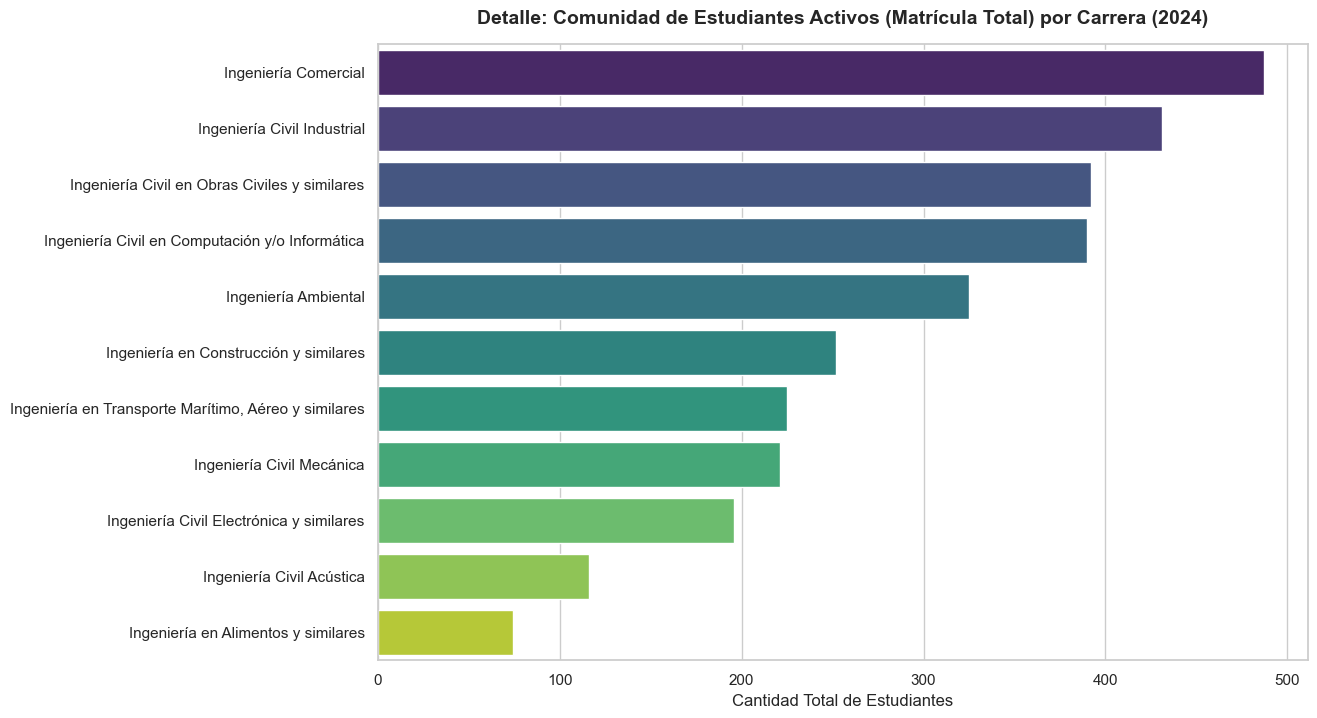

In [26]:
# %% [markdown]
# ## 🏢 GRÁFICO 6: Detalle de Masividad (Alumnos Totales) por Carrera
# Ideal para que los chicos sepan qué tan grande será su comunidad estudiantil.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Asumimos que ya corriste la Celda 1 corregida de carga y limpieza)
#df_ing_2024 = ...

plt.figure(figsize=(12, 8))

# 1. Agrupar por el nombre exacto de la carrera genérica y sumar la matrícula total
# (Matrícula de todos los años académicos, la comunidad total de la carrera)
df_masividad_carrera = df_ing.groupby('Carrera Genérica')['Matrícula Total'].sum().reset_index()

# 2. Ordenamos de mayor a menor masividad
df_masividad_carrera = df_masividad_carrera.sort_values('Matrícula Total', ascending=False)

# Crear el gráfico de barras horizontales
ax = sns.barplot(
    data=df_masividad_carrera,
    x='Matrícula Total',
    y='Carrera Genérica',
    palette='viridis',
    hue='Carrera Genérica', # To avoid warning
    legend=False
)

plt.title('Detalle: Comunidad de Estudiantes Activos (Matrícula Total) por Carrera (2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad Total de Estudiantes', fontsize=12)
plt.ylabel('', fontsize=12)

# Save the figure
plt.savefig('comparacion_detallada_masividad_carrera.png', dpi=300, bbox_inches='tight')
plt.show()